# Wake — 尾场: TESLA 模块尾场表

本 notebook 是官方算例系列示例之一 (全部位于 examples/ 目录): 只跑这一个官方算例, 逐步解读输入卡、展示本算例最有代表性的图。

In [1]:
%run ../notebooks/_bootstrap.py

astra-notebook 后端已加载 (v0.1.0)
项目根目录: /Users/yuxinwu/my_projects/astra_notebook
模拟工作目录: /Users/yuxinwu/my_projects/astra_notebook/data/workspace
ASTRA    : /Users/yuxinwu/programs/ASTRA/astra
Generator: /Users/yuxinwu/programs/ASTRA/generator


In [2]:
# ===== 共享规格 (单一数据源, 与 06 汇总一致) =====
from examples._examples_spec import (
    EXAMPLES, run_example, phase_files, compare_xemit)
NAME = "Wake"
STEM = "Wake"
print("算例:", NAME, "| 物理:", EXAMPLES[NAME]["title"])


算例: Wake | 物理: 尾场: TESLA 模块尾场表


In [3]:
# ===== 运行本算例 (generator/astra 按需) =====
work = run_example(NAME)
print("输出文件:")
for f in sorted(work.glob(STEM + ".*")):
    print("  ", f.name)

 --------------------------------------------------------------------------

                     Astra- A space charge tracking algorithm     
               Version 4.0 - macOS 64bit - OpenMPI - Apple Silicon
                              DESY,  Hamburg 2022                 
                         15. 8.2026  21:47

     Parameter file is:  Wake.in                                           
     DRIFT to z=2.1 with WAKE at 2.0m (from z=1.9)                                   

 Initialize element settings:
     neglecting space charge forces 

 --------------------------------------------------------------------------
 WAKE:

 --------------------------------------------------------------------------
     500 particles from file test.ini                                          

     Particles taken into account      N =        500
     total charge                      Q =     -1.000     nC
     horizontal beam position          x =     3.1742E-05 mm
     vertical beam position   

In [4]:
# ===== 束团统计 (最后一个 z 位置) =====
from astra_tools.io import read_distribution
from astra_tools.analysis.statistics import compute_statistics, print_statistics
from astra_tools.widgets.panels import stats_table_html
ph = phase_files(work, STEM)
dist = read_distribution(ph[-1])
print("相空间文件:", ph[-1].name)
print_statistics(compute_statistics(dist),
                 title="%s @ %s" % (NAME, ph[-1].name))
stats_table_html(compute_statistics(dist))

相空间文件: Wake.0210.001

  Wake @ Wake.0210.001
  Particles:            500 total,      500 active,      0 passive,
                         0 lost,      0 not started
  Total charge:        1.0000 nC (|Q| shown; sign kept internally)
----------------------------------------
  Ref. momentum:     250.4152 MeV/c
  Ref. kinetic E:    249.9047 MeV
  gamma:             490.0513
  beta:              0.999998
----------------------------------------
  Centroid x:          0.0000 mm
  Centroid y:          0.0000 mm
  Centroid z:       2100.0000 mm
  sigma_x:             0.0802 mm
  sigma_y:             0.0802 mm
  sigma_z:             0.9998 mm
----------------------------------------
  Mean pz:           250.4242 MeV/c
  sigma_p/p:         0.000165
  Mean E_kin:        249.9137 MeV
  sigma_E:            41.2437 keV
  sigma_E/E:         0.000165
----------------------------------------
  eps_x (geom):        0.0020 um.rad
  eps_y (geom):        0.0020 um.rad
  eps_nx:              1.0000 um.rad (

quantity,value,unit
n_particle,500,
n_active,500,
n_passive,0,
n_lost,0,
n_not_started,0,
total_charge_nC,1 (|Q|),nC
mean_x_mm,3.51766e-05,mm
mean_y_mm,1.98846e-05,mm
mean_z_mm,2100,mm
sig_x_mm,0.0801564,mm


from astra_tools.io.field_map import read_wake_potential
import matplotlib.pyplot as plt
w = read_wake_potential(work / "TESLA_MODULE_WAKE_TAYLOR.dat")
print("尾场块数:", len(w.blocks))
for bi, blk in enumerate(w.blocks):
    tag = "单极 (monopole)" if bi == 0 else "双极 (dipole %d)" % bi
    print("  block %d: %d 点 (%s)" % (bi + 1, len(blk.s), tag))
    plt.plot(blk.s * 1e3, blk.w, lw=0.8, label="block %d %s" % (bi + 1, tag))
plt.xlabel("s [mm]")
plt.ylabel("W [V/C]")
plt.title("TESLA 模块尾场表")
plt.legend(fontsize=8)
plt.tight_layout()


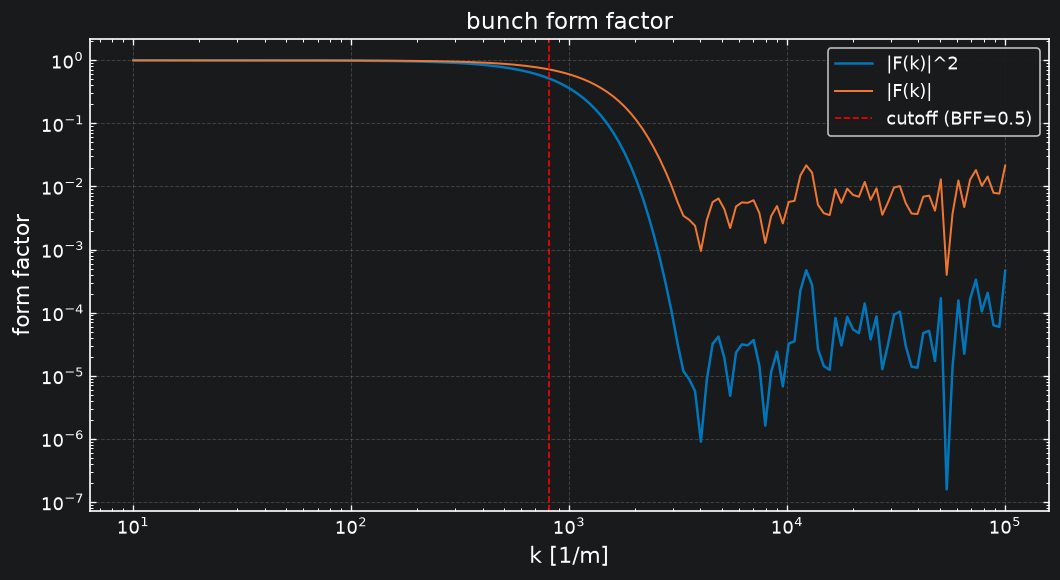

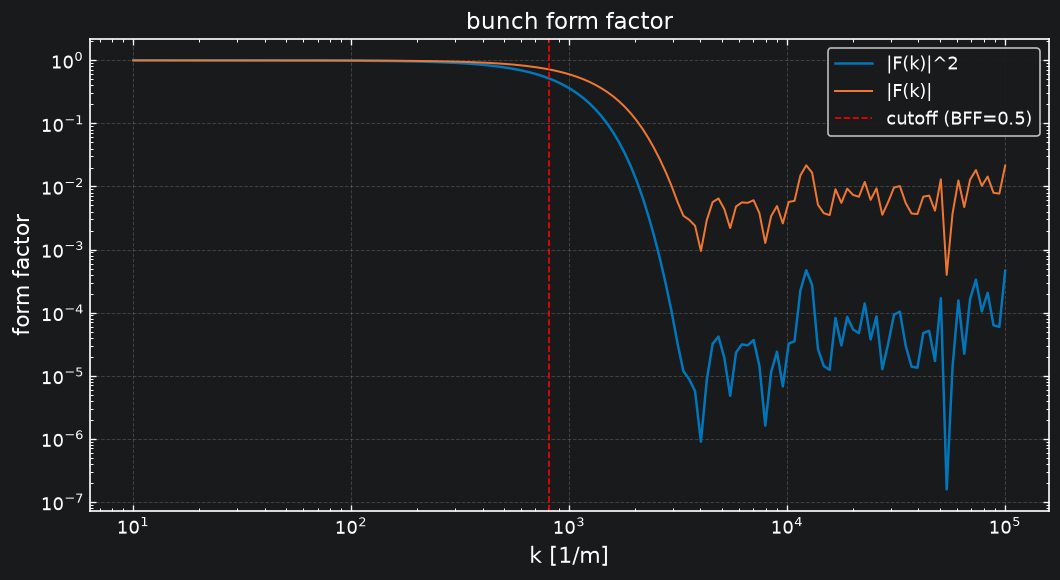

In [5]:
from astra_tools.analysis.bff import compute_bff
from astra_tools.plot.bff_plots import plot_bff_with_amplitude
bff = compute_bff(dist.filter_active().z, dist.filter_active().charge,
                  kmin=10, kmax=1e5, nk=150, detect_features=True)
plot_bff_with_amplitude(bff)

In [6]:
# ===== 黄金比对 (rel < 0.5% 判 OK) =====
compare_xemit(NAME, work)
print("其他官方算例的示例 notebook 同样位于 examples/ 目录")

  末行比对 (new vs golden):
    norm_emit_x    1e-06      1e-06      rel=0.0000% OK
    sigma_x        8.0156e-05 8.0156e-05 rel=0.0000% OK
    mean_z         2.1        2.1        rel=0.0000% OK
返回汇总: notebooks/06_examples.ipynb
